In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

I0000 00:00:1779005165.837252   42819 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779005166.285448   42819 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779005167.906435   42819 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# 1. Hyperparameters
batch_size = 64
epochs = 5
input_shape = (32, 32, 3)
# MobileNetV2 prefers larger inputs, so we will resize inside the model
resized_shape = (96, 96, 3)

In [3]:
# 2. Load and Prepare Data
print("Downloading and preparing CIFAR-10 data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 52s 0us/step


In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [5]:
# 3. Data Augmentation Pipeline
# Building this into the model ensures it only runs during training (on the GPU if available)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

W0000 00:00:1779005225.131338   42902 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779005225.527517   42819 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
# 4. Load Pretrained Model (Transfer Learning)
print("Loading pretrained MobileNetV2...")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=resized_shape,
    include_top=False,
    weights='imagenet'
)

# Freeze the base model to only train the new classification head
base_model.trainable = False

Loading pretrained MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [7]:
# 5. Build the Final Model
inputs = tf.keras.Input(shape=input_shape)
# Apply augmentation
x = data_augmentation(inputs)
# Resize to fit MobileNetV2's minimum optimal size
x = tf.keras.layers.Resizing(96, 96)(x)
# MobileNetV2 specific preprocessing (scales pixels between -1 and 1)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
# Pass through base model
x = base_model(x, training=False)
# Convert features to a single vector per image
x = tf.keras.layers.GlobalAveragePooling2D()(x)
# Add dropout for regularization
x = tf.keras.layers.Dropout(0.2)(x)
# Final output layer
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

In [8]:
# 6. Compile and Train
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
print("Starting training...")
history = model.fit(
    x_train, y_train,
    epochs=epochs,
    validation_data=(x_test, y_test),
    batch_size=batch_size
)

Starting training...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 189s 236ms/step - accuracy: 0.6118 - loss: 1.1357 - val_accuracy: 0.8064 - val_loss: 0.5653
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 197s 252ms/step - accuracy: 0.6790 - loss: 0.9228 - val_accuracy: 0.8093 - val_loss: 0.5533
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 194s 248ms/step - accuracy: 0.6906 - loss: 0.8994 - val_accuracy: 0.8052 - val_loss: 0.5698
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 193s 247ms/step - accuracy: 0.6931 - loss: 0.8840 - val_accuracy: 0.8172 - val_loss: 0.5345
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 186s 237ms/step - accuracy: 0.6915 - loss: 0.8861 - val_accuracy: 0.8088 - val_loss: 0.5659


In [10]:
# 7. Evaluate Metrics
print("\nEvaluating on test data...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")


Evaluating on test data...
313/313 - 34s - 108ms/step - accuracy: 0.8088 - loss: 0.5659
Final Test Accuracy: 80.88%


In [11]:
# 8. Save the Model
save_path = 'cifar10_mobilenetv2.keras'
model.save(save_path)
print(f"Model saved to {save_path}")

Model saved to cifar10_mobilenetv2.keras


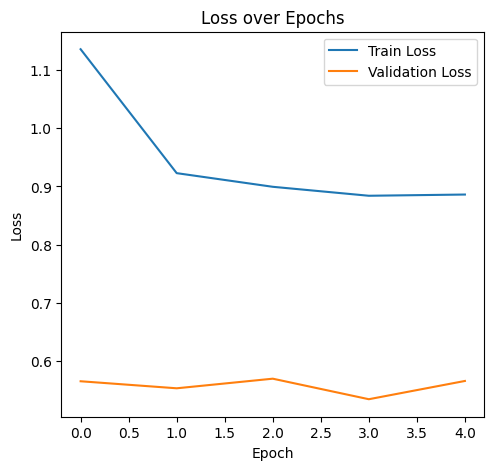

In [12]:
# 9. Plotting Training Curves
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Training curves saved to 'training_curves.png'.


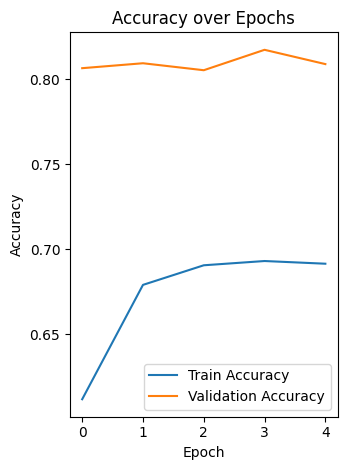

In [13]:
# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
print("Training curves saved to 'training_curves.png'.")
plt.show()